# 1.4 Optical PLL (Laser Lock)

This notebook showcases the **MultiRateLaserLock** loop class, which models the Simulink optical phase-locked loop for heterodyne laser locking. All parameters match the Simulink PLL specification (`PLL-SPEC.md`, `pllParams.mat`).

**Loop topology:** PD → IIR → [RateTransition] → PIII → Delay → DAC → Laser → PreGain → VCO (PA + LUT)

When `sps_adc` (40 MHz) > `sps_loop` (20 MHz), a RateTransitionComponent models the 40→20 MHz downsampling.

## Simulink PLL Parameters (pllParams.mat)

| Parameter | Value | Description |
|-----------|-------|-------------|
| `fLoop` | 20 MHz | Loop update rate |
| `fADC` | 40 MHz | ADC sample rate |
| `sosScaled26` | [16777216, 33554432, 16777216, 16777216, -33181752, 16408629] | IIR SOS coefficients |
| IIR input scale | 2⁻²⁴ | Gain2 (sid 553) |
| IIR output scale | 2⁻¹⁴ | Gain Compensator (sid 705) |
| PIII Kp | 5000 | Proportional gain |
| PIII Ki | 4000 | Integral gain |
| DAC gain | 2/2¹⁶ | Bits-Volts (sid 286) |
| Pre-loop gain | 0.1 | Gain (sid 709) |
| Delay | 1 sample | Pipeline delay |
| lasTFb, lasTFa | (see below) | Laser dynamics (Discrete Transfer Fcn) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import loopkit.loopmath as lm
from loopkit.loops import MultiRateLaserLock

In [2]:
# Simulink PLL parameters (pllParams.mat)
f_loop = 20e6  # fLoop: loop update rate (Hz)
f_adc = 40e6   # fADC: ADC sample rate (Hz) — loop uses fLoop

# Phase detector amplitude (normalized Vpk/Vpp_adc)
Amp = 0.5

# PIII controller gains (linear, from Gain2=5000, Gain4=4000)
Kp = 5000
Ki = 4000

# IIR filter: sosScaled26 from pllParams
sos_scaled26 = [16777216, 33554432, 16777216, 16777216, -33181752, 16408629]
iir_input_scale = 2**-24   # Gain2 (sid 553)
iir_output_scale = 2**-14  # Gain Compensator (sid 705)

# DAC and pre-loop gain
dac_gain = 2 / 2**16      # Bits-Volts (sid 286)
pre_gain = 0.1            # Gain (sid 709)

# Pipeline delay (samples)
n_reg = 1

# Laser dynamics (lasTFb, lasTFa from pllParams) — used by default in MultiRateLaserLock
lasTFb = np.array([-52937.5288030121, 59309.27023733428, 52938.33203142742, -59308.466786107])
lasTFa = np.array([1.0, -2.98154285463868, 2.9631583948738554, -0.9816155352742084,
                   0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# Frequency array for analysis
frfr = np.logspace(np.log10(1e2), np.log10(1e7), int(1e4))

In [3]:
# Build MultiRateLaserLock with all Simulink parameters
# Multi-rate: sps_adc=40 MHz (ADC), sps_loop=20 MHz (loop) — includes RateTransition
pll = MultiRateLaserLock(
    sps_loop=f_loop,
    Amp=Amp,
    Kp=Kp,
    Ki=Ki,
    sps_adc=f_adc,
    sos=sos_scaled26,
    dac_gain=dac_gain,
    pre_gain=pre_gain,
    n_reg=n_reg,
    iir_input_scale=iir_input_scale,
    iir_output_scale=iir_output_scale,
)

# Compute unity gain frequency and phase margin
ugf, margin = lm.get_margin(pll.Gf(f=frfr), frfr, deg=True)
print(f"Unity gain frequency = {ugf:.4e} Hz")
print(f"Phase margin = {margin:.2f} deg")

Unity gain frequency = 1.3763e+05 Hz
Phase margin = 40.51 deg


In [4]:
# List components in the loop (Simulink topology)
print("MultiRateLaserLock components (signal flow):")
for name in pll.components_dict:
    print(f"  {name}")

MultiRateLaserLock components (signal flow):
  PD
  IIR
  RateTransition
  PIII
  Delay
  DAC
  Laser
  PreGain
  PA
  LUT


## Component Bode Plots

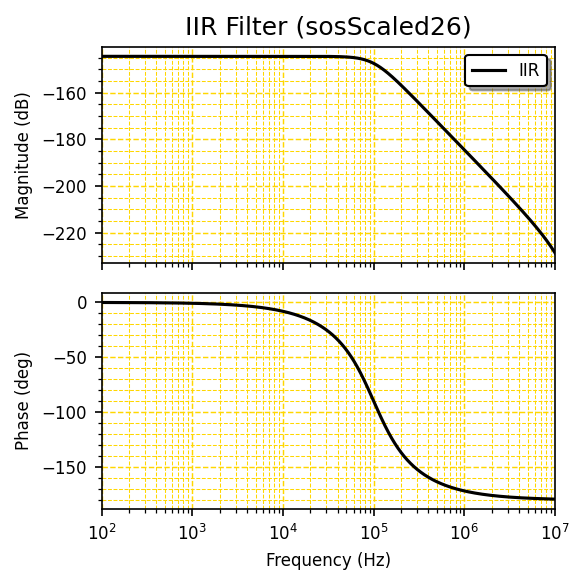

In [5]:
ax = pll.components_dict['IIR'].bode_plot(frfr, dB=True)
ax[0].set_title('IIR Filter (sosScaled26)')
plt.tight_layout()
plt.show()

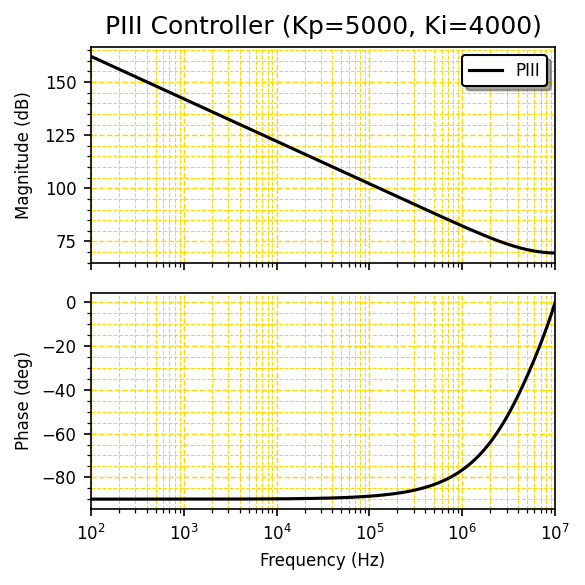

In [6]:
ax = pll.components_dict['PIII'].bode_plot(frfr, dB=True)
ax[0].set_title('PIII Controller (Kp=5000, Ki=4000)')
plt.tight_layout()
plt.show()

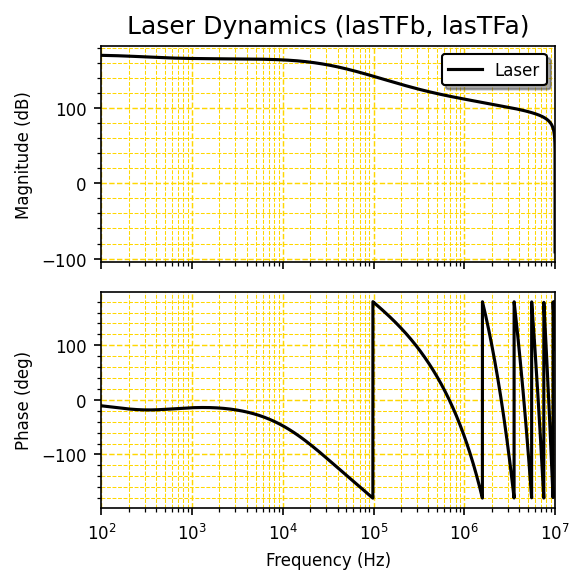

In [7]:
ax = pll.components_dict['Laser'].bode_plot(frfr, dB=True)
ax[0].set_title('Laser Dynamics (lasTFb, lasTFa)')
plt.tight_layout()
plt.show()

## Loop Bode Plot

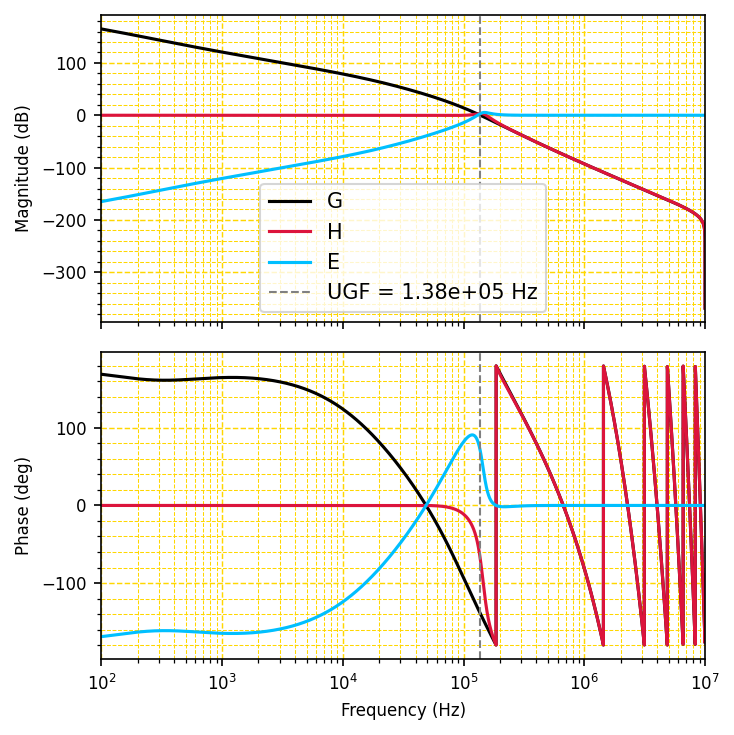

In [8]:
ax = pll.bode_plot(frfr, dB=True)
ax[0].axvline(x=ugf, ls='--', c='gray', lw=1, label=f'UGF = {ugf:.2e} Hz')
ax[1].axvline(x=ugf, ls='--', c='gray', lw=1)
ax[0].legend()
plt.tight_layout()
plt.show()

## Nyquist Plot

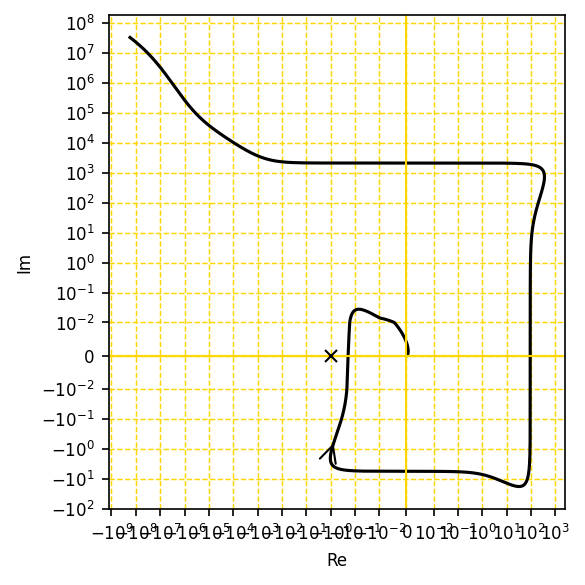

In [9]:
ax = pll.nyquist_plot(
    np.logspace(2, 6, int(1e4)),
    which='G',
    logy=True,
    logx=True,
    arrow_frequency=ugf,
    critical_point=True,
    label=False,
)
plt.tight_layout()
plt.show()

## Point-to-Point Transfer Functions

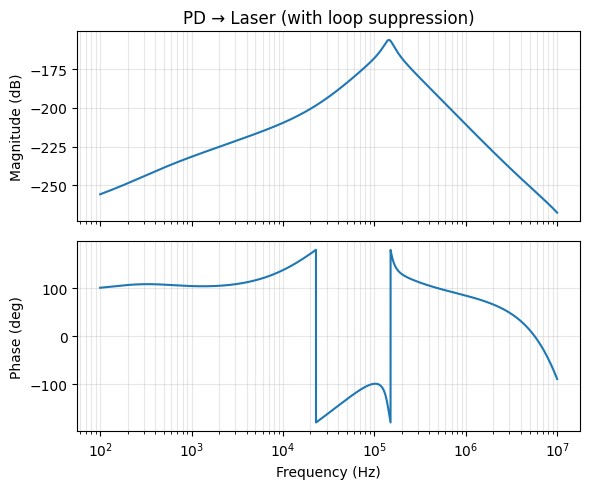

In [ ]:
# Transfer function from PD to Laser (forward path through controller and DAC)
tf_pd_to_laser = pll.point_to_point_component(_from='PD', _to='Laser', suppression=True)
mag, phase = tf_pd_to_laser.bode(frfr, dB=True)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(6, 5), sharex=True)
ax_mag.semilogx(frfr, mag)
ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.set_title('PD → Laser (closed-loop gain)')
ax_mag.grid(True, which='both', alpha=0.3)
ax_phase.semilogx(frfr, phase)
ax_phase.set_ylabel('Phase (deg)')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

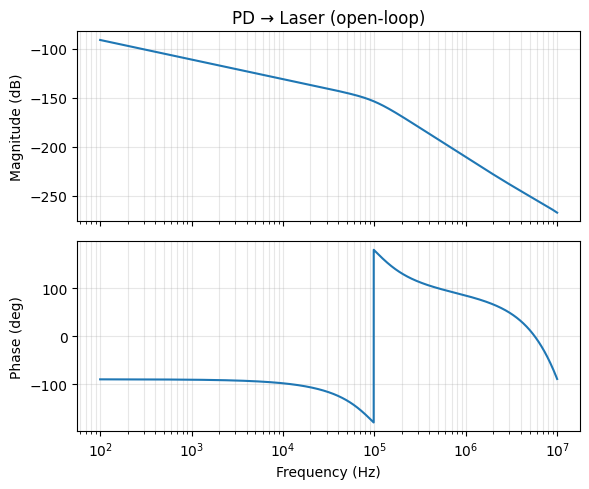

In [ ]:
tf_pd_to_laser = pll.point_to_point_component(_from='PD', _to='Laser', suppression=False)
mag, phase = tf_pd_to_laser.bode(frfr, dB=True)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(6, 5), sharex=True)
ax_mag.semilogx(frfr, mag)
ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.set_title('PD → Laser (open-loop gain)')
ax_mag.grid(True, which='both', alpha=0.3)
ax_phase.semilogx(frfr, phase)
ax_phase.set_ylabel('Phase (deg)')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Block Diagram


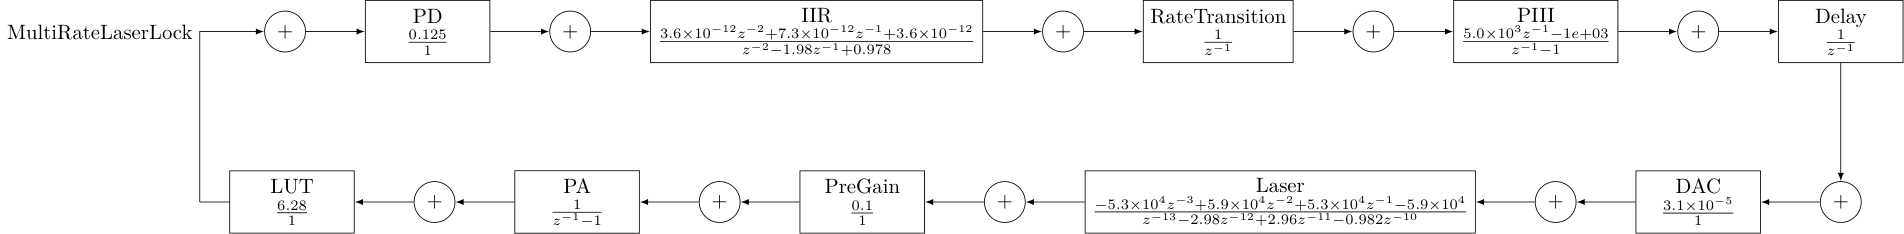

In [11]:
pll.block_diagram(transfer_functions=True)